<a href="https://colab.research.google.com/github/ramiltrinidad-ctrl/maida/blob/main/NumpyandPanda5302026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=143)

df = pd.DataFrame({'g1': ['a', 'a', None, 'b', 'b', 'a', None],
                   'g2': pd.Series([1, 2, 1, 2, 1, None, 1], dtype="Int64"),
                   'data1': rng.integers(10, size=7),
                   'data2': rng.integers(10, size=7)})
df

,g1,g2,data1,data2
0,a,1,9,6
1,a,2,4,8
2,None,1,6,7
3,b,2,9,0
4,b,1,1,8
5,a,<NA>,5,0
6,None,1,7,3


In [2]:
grouped = df['data1'].groupby(df['g1'])
grouped

In [3]:
grouped.mean()

,data1
g1,
a,6.0
b,5.0


In [6]:
grouped = df['data1'].groupby([df['g1'], df['g2']])
grouped.mean()


g1  g2
a   1     9.0
    2     4.0
b   1     1.0
    2     9.0
Name: data1, dtype: float64

In [7]:
means = grouped.mean()
means

g1  g2
a   1     9.0
    2     4.0
b   1     1.0
    2     9.0
Name: data1, dtype: float64

In [12]:
means.reset_index()

,g1,g2,data1
0,a,1,9.0
1,a,2,4.0
2,b,1,1.0
3,b,2,9.0


In [11]:
means

g1  g2
a   1     9.0
    2     4.0
b   1     1.0
    2     9.0
Name: data1, dtype: float64

In [13]:
means.unstack()

g2,1,2
g1,,
a,9.0,4.0
b,1.0,9.0


In [14]:
df.groupby('g2').mean(numeric_only=True)

,data1,data2
g2,,
1,5.75,6.0
2,6.50,4.0


In [15]:
df

,g1,g2,data1,data2
0,a,1,9,6
1,a,2,4,8
2,None,1,6,7
3,b,2,9,0
4,b,1,1,8
5,a,<NA>,5,0
6,None,1,7,3


In [16]:
df.groupby('g2').mean(numeric_only=True)

,data1,data2
g2,,
1,5.75,6.0
2,6.50,4.0


In [17]:
df.groupby('g1')['data1'].mean()

,data1
g1,
a,6.0
b,5.0


In [18]:
for name, group in df.groupby('g1'):
    print(name)
    print(group)
    print('\n')

a
  g1    g2  data1  data2
0  a     1      9      6
1  a     2      4      8
5  a  <NA>      5      0


b
  g1  g2  data1  data2
3  b   2      9      0
4  b   1      1      8




In [19]:
pd.Nan

AttributeError: module 'pandas' has no attribute 'Nan'

In [20]:
rng = np.random.default_rng(seed=143)

people = pd.DataFrame(
    rng.integers(5, size=(5, 5)),
    columns=['a', 'b', 'c', 'd', 'e'],
    index=['Joe', 'Steve', 'Wanda', 'Jill', 'Trey']
)
people

,a,b,c,d,e
Joe,4,2,3,4,0
Steve,2,3,3,4,3
Wanda,0,4,0,1,2
Jill,0,0,2,4,0
Trey,2,1,4,3,1


In [21]:
col_map = {
    'a': 'red',
    'b': 'red',
    'c': 'blue',
    'd': 'blue',
    'e': 'red',
    'f': 'orange'
}

In [22]:
grouped = people.groupby(col_map, axis='columns')
grouped.mean()

/tmp/ipykernel_1978/869958448.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grouped = people.groupby(col_map, axis='columns')


,blue,red
Joe,3.5,2.000000
Steve,3.5,2.666667
Wanda,0.5,2.000000
Jill,3.0,0.000000
Trey,3.5,1.333333


In [23]:
pd.Series(col_map)

,0
a,red
b,red
c,blue
d,blue
e,red
f,orange


In [24]:
people

,a,b,c,d,e
Joe,4,2,3,4,0
Steve,2,3,3,4,3
Wanda,0,4,0,1,2
Jill,0,0,2,4,0
Trey,2,1,4,3,1


In [25]:
people.groupby(len).sum()

,a,b,c,d,e
3,4,2,3,4,0
4,2,1,6,7,1
5,2,7,3,5,5


In [26]:
people.groupby(len)

In [27]:
people.groupby(len).sum()

,a,b,c,d,e
3,4,2,3,4,0
4,2,1,6,7,1
5,2,7,3,5,5


In [28]:
people.groupby(len).min()

,a,b,c,d,e
3,4,2,3,4,0
4,0,0,2,3,0
5,0,3,0,1,2


In [29]:
def peak_to_peak(arr):
    return arr.max() - arr.min()

In [30]:
grouped = df  .groupby('g1')['data1'].agg(peak_to_peak)
grouped

,data1
g1,
a,5
b,8


In [31]:
grouped = df.groupby('g1')
grouped

In [32]:
grouped.agg(peak_to_peak)

,g2,data1,data2
g1,,,
a,1,5,8
b,1,8,8


In [33]:
grouped.agg([peak_to_peak, min, max, sum])

/tmp/ipykernel_1978/2952500177.py:1: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  grouped.agg([peak_to_peak, min, max, sum])
/tmp/ipykernel_1978/2952500177.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  grouped.agg([peak_to_peak, min, max, sum])
/tmp/ipykernel_1978/2952500177.py:1: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  grouped.agg([peak_to_peak, min, max, sum])


g2                    data1                    data2            
   peak_to_peak min max sum peak_to_peak min max sum peak_to_peak min max sum
g1                                                                           
a             1   1   2   3            5   4   9  18            8   0   8  14
b             1   1   2   3            8   1   9  10            8   0   8   8

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
ls

drive/  sample_data/


In [39]:
cd drive/


/content/drive


In [40]:
ls

MyDrive/  Shareddrives/


In [45]:
ls


'2019 ProdMan Plans - Ramil Trinidad v4.gslides'
'2022 Breakthrough Sales Account Planning'/
'2022 MDI Novare PMS Template MANGAHAS, PAULO v1 10052022.xlsx'
'2022 MDI Novare PMS Template MANGAHAS, PAULO v1 1H 08032022.xlsx'
'2022 MDI Novare PMS Template MANGAHAS, PAULO v1 Yr 2022 30Jan2023_RamilReviewed.xlsx'
'2022 Sales and GP_v14_delinked - DAO Rev & GP.xlsx'
'2022 SOs for Validation of PS.xlsx'
'20230313 Request For Proposal (RFP) - Cloud Modernization for Data Platform v4 (2).xlsx'
'2023 MDI Novare Budget Template - Product and Sales Operations.xlsx'
'2023 MDI Novare PMS Template TRINIDAD, RAMIL_1on1SessionDone (1).xlsx'
'2023 MDI Novare PMS Template TRINIDAD, RAMIL_1on1SessionDone.xlsx'
'2024 MDI Novare PMS Template PASCUAL, GABRIELLE QUIRINO - FY2024 (Reviewed).xlsx'
'2024 MDI Novare PMS Template PASCUAL, GABRIELLE QUIRINO - Use for Probationary Goals - with IMFeedback.xlsx'
'2024 Training and Cert Budget Summary - PendingFinanceNego-Approval.xlsx'
'2025 MI Letter CL5-7_TRINIDAD,

In [42]:
ls


'2019 ProdMan Plans - Ramil Trinidad v4.gslides'
'2022 Breakthrough Sales Account Planning'/
'2022 MDI Novare PMS Template MANGAHAS, PAULO v1 10052022.xlsx'
'2022 MDI Novare PMS Template MANGAHAS, PAULO v1 1H 08032022.xlsx'
'2022 MDI Novare PMS Template MANGAHAS, PAULO v1 Yr 2022 30Jan2023_RamilReviewed.xlsx'
'2022 Sales and GP_v14_delinked - DAO Rev & GP.xlsx'
'2022 SOs for Validation of PS.xlsx'
'20230313 Request For Proposal (RFP) - Cloud Modernization for Data Platform v4 (2).xlsx'
'2023 MDI Novare Budget Template - Product and Sales Operations.xlsx'
'2023 MDI Novare PMS Template TRINIDAD, RAMIL_1on1SessionDone (1).xlsx'
'2023 MDI Novare PMS Template TRINIDAD, RAMIL_1on1SessionDone.xlsx'
'2024 MDI Novare PMS Template PASCUAL, GABRIELLE QUIRINO - FY2024 (Reviewed).xlsx'
'2024 MDI Novare PMS Template PASCUAL, GABRIELLE QUIRINO - Use for Probationary Goals - with IMFeedback.xlsx'
'2024 Training and Cert Budget Summary - PendingFinanceNego-Approval.xlsx'
'2025 MI Letter CL5-7_TRINIDAD,

In [46]:
cd PandasExercisewithData/


/content/drive/MyDrive/PandasExercisewithData


In [47]:
ls

data/


In [48]:
cd data/

/content/drive/MyDrive/PandasExercisewithData/data


In [49]:
ls

nba-2023-regular.csv


In [50]:
import /content/drive/MyDrive/PandasExercisewithData/data/nba-2023-regular.csv/

SyntaxError: invalid syntax (2298211741.py, line 1)

In [51]:
ls


nba-2023-regular.csv


In [52]:
data


NameError: name 'data' is not defined

In [53]:
data = pd.read_csv(
    '/content/drive/MyDrive/PandasExercisewithData/data/nba-2023-regular.csv', sep=';', encoding='ISO-8859-1',
).drop_duplicates(subset='Rk').set_index('Rk')
data

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
Rk,,,,,,,,,,,,,,,,,,,,,
1,Precious Achiuwa,C,23,TOR,55,12,20.7,3.6,7.3,0.485,...,0.702,1.8,4.1,6.0,0.9,0.6,0.5,1.1,1.9,9.2
2,Steven Adams,C,29,MEM,42,42,27.0,3.7,6.3,0.597,...,0.364,5.1,6.5,11.5,2.3,0.9,1.1,1.9,2.3,8.6
3,Bam Adebayo,C,25,MIA,75,75,34.6,8.0,14.9,0.540,...,0.806,2.5,6.7,9.2,3.2,1.2,0.8,2.5,2.8,20.4
4,Ochai Agbaji,SG,22,UTA,59,22,20.5,2.8,6.5,0.427,...,0.812,0.7,1.3,2.1,1.1,0.3,0.3,0.7,1.7,7.9
5,Santi Aldama,PF,22,MEM,77,20,21.8,3.2,6.8,0.470,...,0.750,1.1,3.7,4.8,1.3,0.6,0.6,0.8,1.9,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,Thaddeus Young,PF,34,TOR,54,9,14.7,2.0,3.7,0.545,...,0.692,1.3,1.8,3.1,1.4,1.0,0.1,0.8,1.6,4.4
536,Trae Young,PG,24,ATL,73,73,34.8,8.2,19.0,0.429,...,0.886,0.8,2.2,3.0,10.2,1.1,0.1,4.1,1.4,26.2
537,Omer Yurtseven,C,24,MIA,9,0,9.2,1.8,3.0,0.593,...,0.833,0.9,1.7,2.6,0.2,0.2,0.2,0.4,1.8,4.4


In [54]:
def top_players(df, n=5, columns='PTS'):
    return df.sort_values(columns, ascending=False)[:n]

In [55]:
top_players(data)

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
Rk,,,,,,,,,,,,,,,,,,,,,
143,Joel Embiid,C,28,PHI,66,66,34.6,11.0,20.1,0.548,...,0.857,1.7,8.4,10.2,4.2,1.0,1.7,3.4,3.1,33.1
125,Luka Don?i?,PG,23,DAL,66,66,36.2,10.9,22.0,0.496,...,0.742,0.8,7.8,8.6,8.0,1.4,0.5,3.6,2.5,32.4
292,Damian Lillard,PG,32,POR,58,58,36.3,9.6,20.7,0.463,...,0.914,0.8,4.0,4.8,7.3,0.9,0.3,3.3,1.9,32.2
164,Shai Gilgeous-Alexander,PG,24,OKC,68,68,35.5,10.4,20.3,0.510,...,0.905,0.9,4.0,4.8,5.5,1.6,1.0,2.8,2.8,31.4
11,Giannis Antetokounmpo,PF,28,MIL,63,63,32.1,11.2,20.3,0.553,...,0.645,2.2,9.6,11.8,5.7,0.8,0.8,3.9,3.1,31.1


In [56]:
# The 'import timedelta' statement imports the 'timedelta' class from the 'datetime' module.
# A `timedelta` object represents a duration, the difference between two dates or times.
# It is useful for performing arithmetic with datetime objects, such as adding or subtracting days, hours, minutes, or seconds.

# Example usage of timedelta:
# from datetime import datetime, timedelta
# start_date = datetime(2023, 1, 1)
# future_date = start_date + timedelta(days=5, hours=3)
# print(future_date)

# Original code from this cell:
# top_players(data)['PTS']

,PTS
Rk,
143,33.1
125,32.4
292,32.2
164,31.4
11,31.1


In [57]:
data.groupby('Tm').apply(top_players, n=1, columns='BLK')


/tmp/ipykernel_1978/836302400.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data.groupby('Tm').apply(top_players, n=1, columns='BLK')


,,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
Tm,Rk,,,,,,,,,,,,,,,,,,,,,
ATL,372,Onyeka Okongwu,C,22,ATL,80,18,23.1,4.0,6.2,0.638,...,0.781,2.7,4.5,7.2,1.0,0.7,1.3,1.0,3.1,9.9
BOS,524,Robert Williams,C,25,BOS,35,20,23.5,3.6,4.9,0.747,...,0.610,3.0,5.4,8.3,1.4,0.6,1.4,1.0,1.9,8.0
BRK,94,Nic Claxton,C,23,BRK,76,76,29.9,5.4,7.7,0.705,...,0.541,2.4,6.8,9.2,1.9,0.9,2.5,1.3,2.8,12.6
CHI,523,Patrick Williams,PF,21,CHI,82,65,28.3,3.8,8.3,0.464,...,0.857,1.0,3.0,4.0,1.2,0.9,0.9,1.2,1.8,10.2
CHO,500,P.J. Washington,PF,24,CHO,73,73,32.6,5.9,13.4,0.444,...,0.730,1.0,3.9,4.9,2.4,0.9,1.1,1.5,2.6,15.7
CLE,339,Evan Mobley,PF,21,CLE,79,79,34.4,6.6,12.0,0.554,...,0.674,2.4,6.6,9.0,2.8,0.8,1.5,1.8,2.8,16.2
DAL,531,Christian Wood,C,27,DAL,67,17,25.9,5.9,11.5,0.515,...,0.772,1.3,6.0,7.3,1.8,0.4,1.1,1.8,2.5,16.6
DEN,169,Aaron Gordon,PF,27,DEN,68,68,30.2,6.3,11.2,0.564,...,0.608,2.4,4.1,6.6,3.0,0.8,0.8,1.4,1.9,16.3
DET,482,Stanley Umude,SG,23,DET,1,0,2.0,0.0,1.0,0.000,...,1.000,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

In [60]:
now = datetime.now()

In [61]:
now

datetime.datetime(2026, 5, 30, 3, 6, 35, 580315)

In [62]:
now.year, now.month, now.day

(2026, 5, 30)

In [63]:
delta = datetime(2011, 1, 7) - datetime(2000, 6, 24, 8, 15)
delta

datetime.timedelta(days=3848, seconds=56700)

In [64]:
delta.days

3848

In [65]:
from datetime import timedelta


In [66]:
start = datetime(2011, 1, 7)
start + timedelta(12)

datetime.datetime(2011, 1, 19, 0, 0)

In [67]:
start - 2 * timedelta(seconds=10)

datetime.datetime(2011, 1, 6, 23, 59, 40)

In [68]:
start.strftime('%Y-%m-%d')

'2011-01-07'

In [69]:
str(start)

'2011-01-07 00:00:00'

In [70]:
start.strftime('%Y-%m-%d %H:%M:%S')

'2011-01-07 00:00:00'

In [71]:
start.strftime('%d <TEST> %b %Y')

'07 <TEST> Jan 2011'

In [75]:
value = '2011-13-03'

datetime.strptime(value, "%Y-%m-%d")

ValueError: time data '2011-13-03' does not match format '%Y-%m-%d'

In [76]:
value = '2011-03-03'

In [77]:
value = '2011-03-03'

datetime.strptime(value, "%Y-%m-%d")

datetime.datetime(2011, 3, 3, 0, 0)

In [78]:
datestrs = ['7/5/2022 12:00:00', '8/6/2011 00:00:00']
pd.to_datetime(datestrs, dayfirst=True)

DatetimeIndex(['2022-05-07 12:00:00', '2011-06-08 00:00:00'], dtype='datetime64[ns]', freq=None)

In [79]:
rng = np.random.default_rng(1337)
time_series = pd.Series(rng.integers(10, size=1000),
                        index=pd.date_range('2022-01-01', periods=1000))
time_series

,0
2022-01-01,5
2022-01-02,8
2022-01-03,7
2022-01-04,1
2022-01-05,5
...,...
2024-09-22,6
2024-09-23,0
2024-09-24,9
2024-09-25,8


In [80]:
timeseries.index

NameError: name 'timeseries' is not defined

In [81]:
time_series.index

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10',
               ...
               '2024-09-17', '2024-09-18', '2024-09-19', '2024-09-20',
               '2024-09-21', '2024-09-22', '2024-09-23', '2024-09-24',
               '2024-09-25', '2024-09-26'],
              dtype='datetime64[ns]', length=1000, freq='D')

In [82]:
time_series['2024-03-09':'2024-06-12']

,0
2024-03-09,6
2024-03-10,7
2024-03-11,5
2024-03-12,0
2024-03-13,6
...,...
2024-06-08,4
2024-06-09,5
2024-06-10,7
2024-06-11,8


In [83]:
time_series[datetime(2024, 3, 9):'2024-06-12']

,0
2024-03-09,6
2024-03-10,7
2024-03-11,5
2024-03-12,0
2024-03-13,6
...,...
2024-06-08,4
2024-06-09,5
2024-06-10,7
2024-06-11,8


In [84]:
start_date = datetime(2024, 3, 9)
time_series[start_date:start_date + timedelta(days=100)]

,0
2024-03-09,6
2024-03-10,7
2024-03-11,5
2024-03-12,0
2024-03-13,6
...,...
2024-06-13,1
2024-06-14,8
2024-06-15,5
2024-06-16,4


In [85]:
ts_index = pd.date_range('2024-01-01', '2024-12-31')
ts_index


DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2024-12-22', '2024-12-23', '2024-12-24', '2024-12-25',
               '2024-12-26', '2024-12-27', '2024-12-28', '2024-12-29',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', length=366, freq='D')

In [87]:
ts_index = pd.date_range('2024-01-01', periods=20)
ts_index

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10', '2024-01-11', '2024-01-12',
               '2024-01-13', '2024-01-14', '2024-01-15', '2024-01-16',
               '2024-01-17', '2024-01-18', '2024-01-19', '2024-01-20'],
              dtype='datetime64[ns]', freq='D')

In [88]:
ts_index = pd.date_range(end='2024-01-01', periods=20)
ts_index

DatetimeIndex(['2023-12-13', '2023-12-14', '2023-12-15', '2023-12-16',
               '2023-12-17', '2023-12-18', '2023-12-19', '2023-12-20',
               '2023-12-21', '2023-12-22', '2023-12-23', '2023-12-24',
               '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',
               '2023-12-29', '2023-12-30', '2023-12-31', '2024-01-01'],
              dtype='datetime64[ns]', freq='D')

In [89]:
ts_index = pd.date_range('2024-01-01', '2024-12-31', freq='BME')
ts_index

DatetimeIndex(['2024-01-31', '2024-02-29', '2024-03-29', '2024-04-30',
               '2024-05-31', '2024-06-28', '2024-07-31', '2024-08-30',
               '2024-09-30', '2024-10-31', '2024-11-29', '2024-12-31'],
              dtype='datetime64[ns]', freq='BME')

In [90]:
help(pd.date_range)

Help on function date_range in module pandas.core.indexes.datetimes:

date_range(start=None, end=None, periods=None, freq=None, tz=None, normalize: 'bool' = False, name: 'Hashable | None' = None, inclusive: 'IntervalClosedType' = 'both', *, unit: 'str | None' = None, **kwargs) -> 'DatetimeIndex'
    Return a fixed frequency DatetimeIndex.

    Returns the range of equally spaced time points (where the difference between any
    two adjacent points is specified by the given frequency) such that they all
    satisfy `start <[=] x <[=] end`, where the first one and the last one are, resp.,
    the first and last time points in that range that fall on the boundary of ``freq``
    (if given as a frequency string) or that are valid for ``freq`` (if given as a
    :class:`pandas.tseries.offsets.DateOffset`). (If exactly one of ``start``,
    ``end``, or ``freq`` is *not* specified, this missing parameter can be computed
    given ``periods``, the number of timesteps in the range. See the note

In [91]:
ts_index = pd.date_range('2024-01-01 12:30:33', periods=5, normalize='True')
ts_index

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05'],
              dtype='datetime64[ns]', freq='D')

In [92]:
from pandas.tseries.offsets import Hour, Minute

hour = Hour()
hour

<Hour>

In [93]:
four_hours = Hour(4)
four_hours

pd.date_range('2024-03-06', '2024-03-08', freq=four_hours)

DatetimeIndex(['2024-03-06 00:00:00', '2024-03-06 04:00:00',
               '2024-03-06 08:00:00', '2024-03-06 12:00:00',
               '2024-03-06 16:00:00', '2024-03-06 20:00:00',
               '2024-03-07 00:00:00', '2024-03-07 04:00:00',
               '2024-03-07 08:00:00', '2024-03-07 12:00:00',
               '2024-03-07 16:00:00', '2024-03-07 20:00:00',
               '2024-03-08 00:00:00'],
              dtype='datetime64[ns]', freq='4h')

In [94]:
pd.date_range('2024-03-06', '2024-03-08', freq='4h')

DatetimeIndex(['2024-03-06 00:00:00', '2024-03-06 04:00:00',
               '2024-03-06 08:00:00', '2024-03-06 12:00:00',
               '2024-03-06 16:00:00', '2024-03-06 20:00:00',
               '2024-03-07 00:00:00', '2024-03-07 04:00:00',
               '2024-03-07 08:00:00', '2024-03-07 12:00:00',
               '2024-03-07 16:00:00', '2024-03-07 20:00:00',
               '2024-03-08 00:00:00'],
              dtype='datetime64[ns]', freq='4h')

In [95]:
from pandas.tseries.offsets import WeekOfMonth



In [96]:
third_friday_of_month = WeekOfMonth(week=2, weekday=4)

monthly_dates = pd.date_range('2024-01-01', '2024-12-31', freq=third_friday_of_month)
monthly_dates

DatetimeIndex(['2024-01-19', '2024-02-16', '2024-03-15', '2024-04-19',
               '2024-05-17', '2024-06-21', '2024-07-19', '2024-08-16',
               '2024-09-20', '2024-10-18', '2024-11-15', '2024-12-20'],
              dtype='datetime64[ns]', freq='WOM-3FRI')

In [99]:
rng = np.random.default_rng(1337)
ts = pd.Series(
    rng.integers(10, size=10),
    index=pd.date_range('2024-03-01', periods=10, freq='MS')
)
ts

,0
2024-03-01,5
2024-04-01,8
2024-05-01,7
2024-06-01,1
2024-07-01,5
2024-08-01,9
2024-09-01,3
2024-10-01,9
2024-11-01,2
2024-12-01,8


In [100]:
ts.shift(1)

,0
2024-03-01,NaN
2024-04-01,5.0
2024-05-01,8.0
2024-06-01,7.0
2024-07-01,1.0
2024-08-01,5.0
2024-09-01,9.0
2024-10-01,3.0
2024-11-01,9.0
2024-12-01,2.0


In [101]:
ts


,0
2024-03-01,5
2024-04-01,8
2024-05-01,7
2024-06-01,1
2024-07-01,5
2024-08-01,9
2024-09-01,3
2024-10-01,9
2024-11-01,2
2024-12-01,8


In [102]:
ts.shift(-2)

,0
2024-03-01,7.0
2024-04-01,1.0
2024-05-01,5.0
2024-06-01,9.0
2024-07-01,3.0
2024-08-01,9.0
2024-09-01,2.0
2024-10-01,8.0
2024-11-01,NaN
2024-12-01,NaN


In [103]:
ts.shift(-2).shift(1)

,0
2024-03-01,NaN
2024-04-01,7.0
2024-05-01,1.0
2024-06-01,5.0
2024-07-01,9.0
2024-08-01,3.0
2024-09-01,9.0
2024-10-01,2.0
2024-11-01,8.0
2024-12-01,NaN


In [104]:
ts / ts.shift(1)

,0
2024-03-01,NaN
2024-04-01,1.600000
2024-05-01,0.875000
2024-06-01,0.142857
2024-07-01,5.000000
2024-08-01,1.800000
2024-09-01,0.333333
2024-10-01,3.000000
2024-11-01,0.222222
2024-12-01,4.000000


In [105]:
ts / ts.shift(1) - 1

,0
2024-03-01,NaN
2024-04-01,0.600000
2024-05-01,-0.125000
2024-06-01,-0.857143
2024-07-01,4.000000
2024-08-01,0.800000
2024-09-01,-0.666667
2024-10-01,2.000000
2024-11-01,-0.777778
2024-12-01,3.000000


In [106]:
p = pd.Period('2021', freq='Y-DEC')

In [107]:
p

Period('2021', 'Y-DEC')

In [108]:
p.asfreq('M', how='start')

Period('2021-01', 'M')

In [109]:
p=pd.Period('2021Q4', freq='Q-JAN')

In [110]:
p

Period('2021Q4', 'Q-JAN')

In [111]:
rng = np.random.default_rng(1337)
dates = pd.date_range('2024-01-01', periods=3, freq='ME')
ts = pd.Series(rng.integers(10, size=3), index=dates)
ts

,0
2024-01-31,5
2024-02-29,8
2024-03-31,7


In [112]:
ts.to_period()

,0
2024-01,5
2024-02,8
2024-03,7


In [113]:
ts.to_period('Q-JAN')

,0
2024Q4,5
2025Q1,8
2025Q1,7


In [115]:
rng = np.random.default_rng(1337)
dates = pd.date_range('2024-01-01', periods=100)
ts = pd.Series(rng.integers(10, size=100), index=dates)
ts

,0
2024-01-01,5
2024-01-02,8
2024-01-03,7
2024-01-04,1
2024-01-05,5
...,...
2024-04-05,3
2024-04-06,0
2024-04-07,8
2024-04-08,2


In [116]:
ts.to_period('M').to_timestamp()

,0
2024-01-01,5
2024-01-01,8
2024-01-01,7
2024-01-01,1
2024-01-01,5
...,...
2024-04-01,3
2024-04-01,0
2024-04-01,8
2024-04-01,2


In [117]:
rng = np.random.default_rng(1337)
dates = pd.date_range('2000-01-01', periods=100)
ts = pd.Series(rng.integers(10, size=100), index=dates)
ts

,0
2000-01-01,5
2000-01-02,8
2000-01-03,7
2000-01-04,1
2000-01-05,5
...,...
2000-04-05,3
2000-04-06,0
2000-04-07,8
2000-04-08,2


In [118]:
ts.resample('ME').mean()

,0
2000-01-31,4.032258
2000-02-29,4.724138
2000-03-31,4.483871
2000-04-30,3.666667


In [119]:
ts.resample('MS').mean()

,0
2000-01-01,4.032258
2000-02-01,4.724138
2000-03-01,4.483871
2000-04-01,3.666667


In [121]:
dates = pd.date_range('2000-01-01', periods=12, freq='min')
ts = pd.Series(np.arange(1, len(dates) + 1), index=dates)
ts

,0
2000-01-01 00:00:00,1
2000-01-01 00:01:00,2
2000-01-01 00:02:00,3
2000-01-01 00:03:00,4
2000-01-01 00:04:00,5
2000-01-01 00:05:00,6
2000-01-01 00:06:00,7
2000-01-01 00:07:00,8
2000-01-01 00:08:00,9
2000-01-01 00:09:00,10


In [122]:
ts.resample('5min').sum()


,0
2000-01-01 00:00:00,15
2000-01-01 00:05:00,40
2000-01-01 00:10:00,23


In [123]:
ts.resample('5min', closed='right').sum()

,0
1999-12-31 23:55:00,1
2000-01-01 00:00:00,20
2000-01-01 00:05:00,45
2000-01-01 00:10:00,12


In [125]:
rng = np.random.default_rng(1337)
dates = pd.date_range('2000-01-01', periods=12, freq='min')
ts = pd.Series(rng.integers(10, size=len(dates)), index=dates)
ts

,0
2000-01-01 00:00:00,5
2000-01-01 00:01:00,8
2000-01-01 00:02:00,7
2000-01-01 00:03:00,1
2000-01-01 00:04:00,5
2000-01-01 00:05:00,9
2000-01-01 00:06:00,3
2000-01-01 00:07:00,9
2000-01-01 00:08:00,2
2000-01-01 00:09:00,8


In [126]:
ts.resample('5min').ohlc()

,open,high,low,close
2000-01-01 00:00:00,5,8,1,5
2000-01-01 00:05:00,9,9,2,8
2000-01-01 00:10:00,4,4,1,1


In [127]:
rng = np.random.default_rng(1337)
dates = pd.date_range('2000-01-01', periods=2, freq='W-WED')
ts = pd.Series(rng.integers(10, size=len(dates)), index=dates)
ts

,0
2000-01-05,5
2000-01-12,8


In [128]:
rng = np.random.default_rng(1337)
dates = pd.date_range('2000-01-01', periods=2, freq='W-WED')
data = pd.DataFrame(
    rng.integers(10, size=(2, 4)),
    index=dates,
    columns=['Makati', 'QC', 'Pasig', 'Manila']
)
data


,Makati,QC,Pasig,Manila
2000-01-05,5,8,7,1
2000-01-12,5,9,3,9


In [129]:
data.resample('D').asfreq()

,Makati,QC,Pasig,Manila
2000-01-05,5.0,8.0,7.0,1.0
2000-01-06,NaN,NaN,NaN,NaN
2000-01-07,NaN,NaN,NaN,NaN
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,5.0,9.0,3.0,9.0


In [130]:
data.resample('D').ffill()

,Makati,QC,Pasig,Manila
2000-01-05,5,8,7,1
2000-01-06,5,8,7,1
2000-01-07,5,8,7,1
2000-01-08,5,8,7,1
2000-01-09,5,8,7,1
2000-01-10,5,8,7,1
2000-01-11,5,8,7,1
2000-01-12,5,9,3,9


In [131]:
data.resample('D').bfill()

,Makati,QC,Pasig,Manila
2000-01-05,5,8,7,1
2000-01-06,5,9,3,9
2000-01-07,5,9,3,9
2000-01-08,5,9,3,9
2000-01-09,5,9,3,9
2000-01-10,5,9,3,9
2000-01-11,5,9,3,9
2000-01-12,5,9,3,9


In [132]:
data.resample('D').ffill(2)

,Makati,QC,Pasig,Manila
2000-01-05,5.0,8.0,7.0,1.0
2000-01-06,5.0,8.0,7.0,1.0
2000-01-07,5.0,8.0,7.0,1.0
2000-01-08,NaN,NaN,NaN,NaN
2000-01-09,NaN,NaN,NaN,NaN
2000-01-10,NaN,NaN,NaN,NaN
2000-01-11,NaN,NaN,NaN,NaN
2000-01-12,5.0,9.0,3.0,9.0


In [134]:
data = pd.read_csv('/content/drive/MyDrive/PandasExercisewithData/data/AAPL.csv', parse_dates=['Date'], index_col=0)
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400
...,...,...,...,...,...,...
2020-03-26,246.520004,258.679993,246.360001,258.440002,258.440002,63021800
2020-03-27,252.750000,255.869995,247.050003,247.740005,247.740005,51054200
2020-03-30,250.740005,255.520004,249.399994,254.809998,254.809998,41994100


Text(0.5, 1.0, 'AAPL')

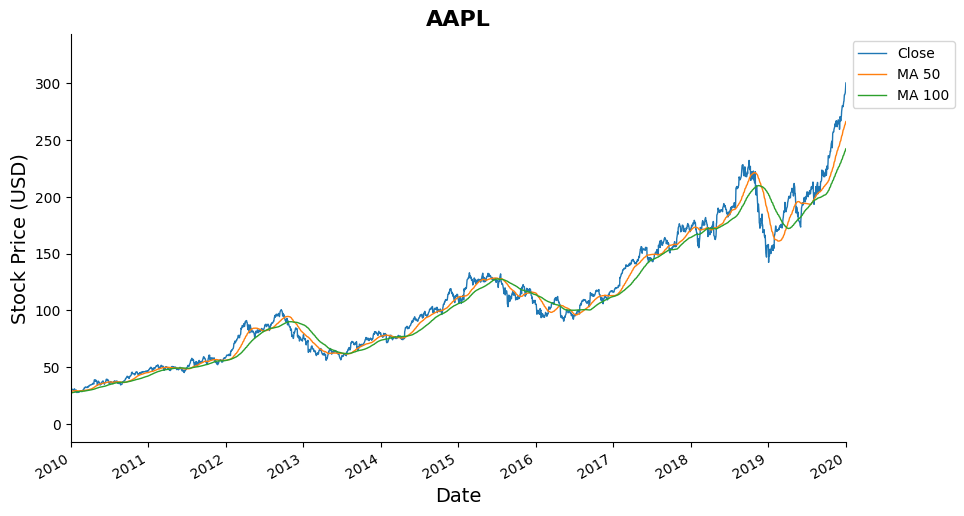

In [143]:
from matplotlib import rcParams

rcParams.update({'figure.figsize': (10, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 14,
                 'axes.titlesize': 16, 'axes.titleweight': 'bold',
                 'figure.titlesize': 18, 'figure.titleweight': 'bold',
                 'lines.linewidth': 1})

ax = data.Close.plot(label='Close')
data.rolling(50).mean().Close.plot(ax=ax, label='MA 50')

(data                        # grab the data
 .rolling(100)           # section it into overlapping windows of 100 days
 .mean()                 # get the average per window
 .Close                  # get the Close column of each window
 .plot(ax=ax, label='MA 100'))  # plot the averaged close column as a time series

ax.legend(loc='upper left', bbox_to_anchor=(1., 1.))
ax.set_xlim(['2010', '2020'])
ax.set_ylabel("Stock Price (USD)")
ax.set_title("AAPL")


Text(0.5, 1.0, 'AAPL')

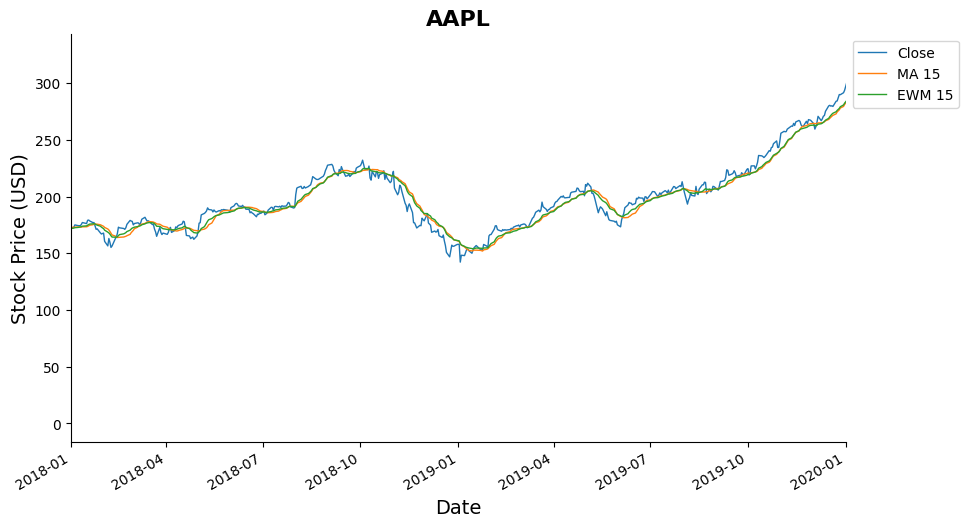

In [144]:
ax = data.Close.plot(label='Close')
data.rolling(15).mean().Close.plot(ax=ax, label='MA 15')
data.ewm(span=15).mean().Close.plot(ax=ax, label='EWM 15')

ax.legend(loc='upper left', bbox_to_anchor=(1., 1.))
ax.set_xlim(['2018', '2020'])
ax.set_ylabel("Stock Price (USD)")
ax.set_title("AAPL")

In [146]:
aapl = pd.read_csv('/content/drive/MyDrive/PandasExercisewithData/data/AAPL.csv', parse_dates=['Date'], index_col=0)
msft = pd.read_csv('/content/drive/MyDrive/PandasExercisewithData/data/MSFT.csv', parse_dates=['Date'], index_col=0)


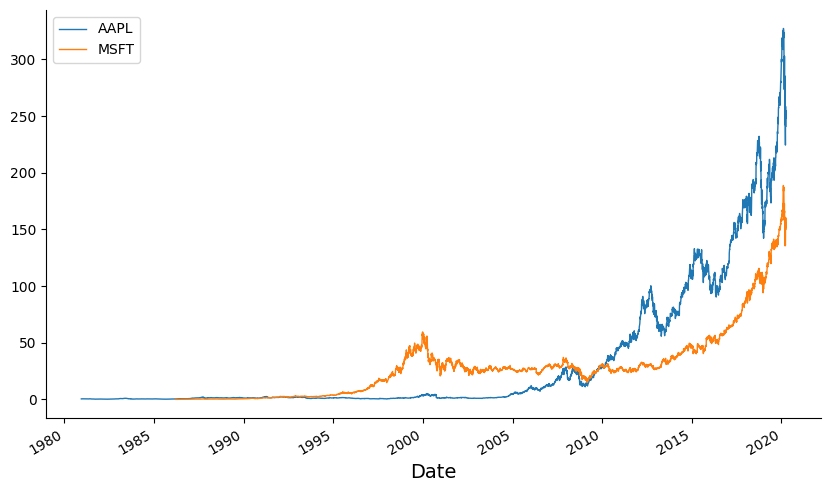

In [147]:
returns_aapl = aapl.pct_change()
returns_msft = msft.pct_change()

ax = aapl.Close.plot(label='AAPL')
msft.Close.plot(ax=ax, label='MSFT')
ax.legend()

In [150]:
returns_aapl.rolling(125).Close.corr(returns_msft.close).plot()

AttributeError: 'DataFrame' object has no attribute 'close'